# 03 — Relationships: Análisis Bivariado y Multivariado
**Entender cómo las variables se relacionan entre sí.**

## Correlación de Pearson
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}} \in [-1, 1]$$
Mide asociación **lineal**. Sensible a outliers. Asume distribución aproximadamente normal.

## Correlación de Spearman
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$
Correlación de **rangos** — no asume linealidad, robusta ante outliers. Preferida para datos sesgados.

## Cramér's V (categórica vs. categórica)
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1, c-1)}} \in [0, 1]$$
Mide asociación entre dos variables categóricas. 0 = independencia, 1 = asociación perfecta.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})

rng = np.random.default_rng(42)
n = 5000
categories = rng.choice(['Electronics','Clothing','Home','Sports','Books','Beauty'], n, p=[0.25,0.22,0.18,0.15,0.12,0.08])
countries  = rng.choice(['US','UK','DE','MX','BR','FR','CA'], n, p=[0.35,0.15,0.12,0.10,0.10,0.10,0.08])
channels   = rng.choice(['organic','paid','email','direct','affiliate'], n, p=[0.30,0.25,0.20,0.15,0.10])
devices    = rng.choice(['mobile','desktop','tablet'], n, p=[0.55,0.35,0.10])
price      = np.where(categories=='Electronics', rng.lognormal(4.5,0.8,n),
             np.where(categories=='Clothing',    rng.lognormal(3.5,0.6,n),
                                                 rng.lognormal(3.2,0.7,n))).round(2)
qty        = rng.integers(1,8,n)
discount   = np.where(rng.uniform(0,1,n)<0.3, rng.uniform(0.05,0.40,n), 0.0).round(2)
revenue    = (price * qty * (1 - discount)).round(2)
rating     = rng.choice([1,2,3,4,5], n, p=[0.05,0.10,0.20,0.40,0.25]).astype(float)
revenue[rng.choice(n,15,replace=False)] = rng.uniform(5000,15000,15)

df = pd.DataFrame({
    'category':categories,'country':countries,'channel':channels,'device':devices,
    'price':price,'quantity':qty,'discount':discount,'revenue':revenue,'rating':rating,
})
print(f'Dataset: {df.shape}')

Dataset: (5000, 9)


## 1 — Scatter plots: numérica vs. numérica

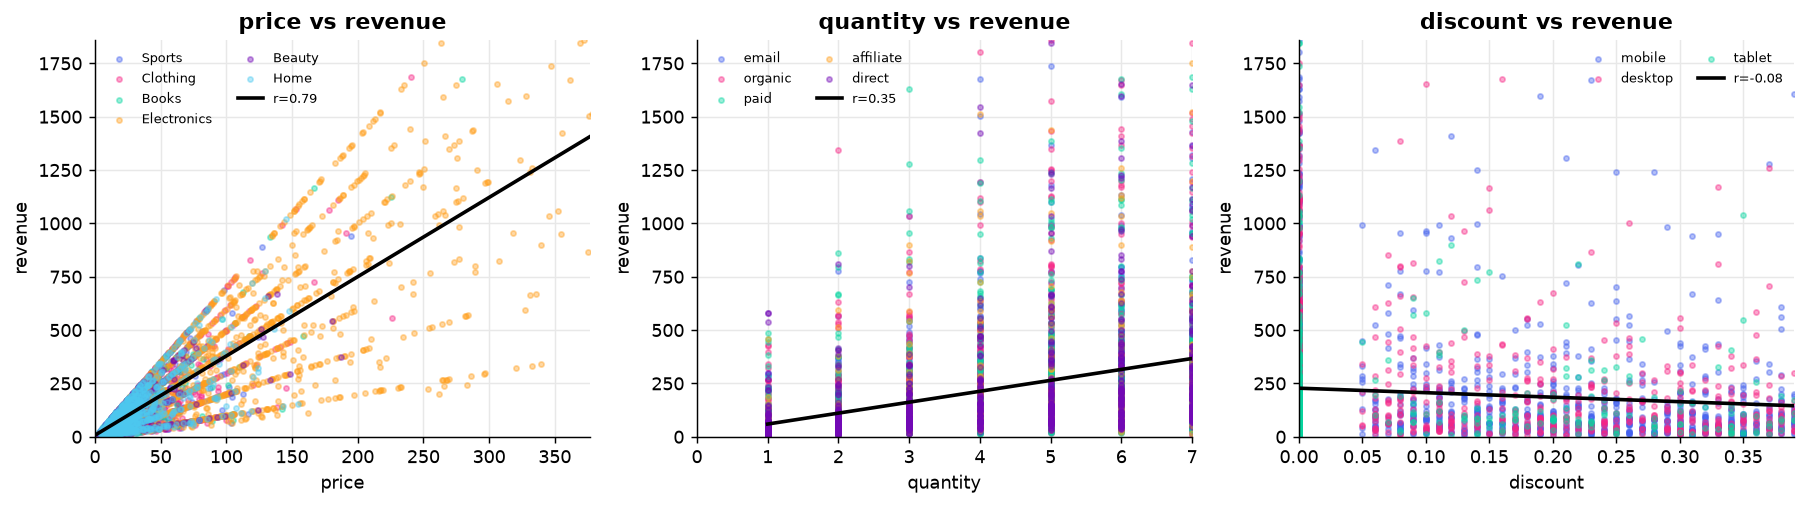

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ('price',    'revenue',  'category'),
    ('quantity', 'revenue',  'channel'),
    ('discount', 'revenue',  'device'),
]
colors = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7','#4cc9f0','#adb5bd']

for ax, (x_col, y_col, hue_col) in zip(axes, pairs):
    groups = df[hue_col].unique()
    for grp, color in zip(groups, colors):
        mask = df[hue_col] == grp
        ax.scatter(df.loc[mask, x_col], df.loc[mask, y_col],
                   s=8, alpha=0.4, color=color, label=grp)

    # Línea de tendencia (sobre todo el dataset)
    x_clean = df[x_col].clip(upper=df[x_col].quantile(0.99))
    y_clean = df[y_col].clip(upper=df[y_col].quantile(0.99))
    slope, intercept, r, *_ = stats.linregress(x_clean, y_clean)
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=2, label=f'r={r:.2f}')

    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.set_xlim(left=0, right=df[x_col].quantile(0.99))
    ax.set_ylim(bottom=0, top=df[y_col].quantile(0.99))
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

## 2 — Heatmap de correlaciones: Pearson vs. Spearman

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_16870/3403480589.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


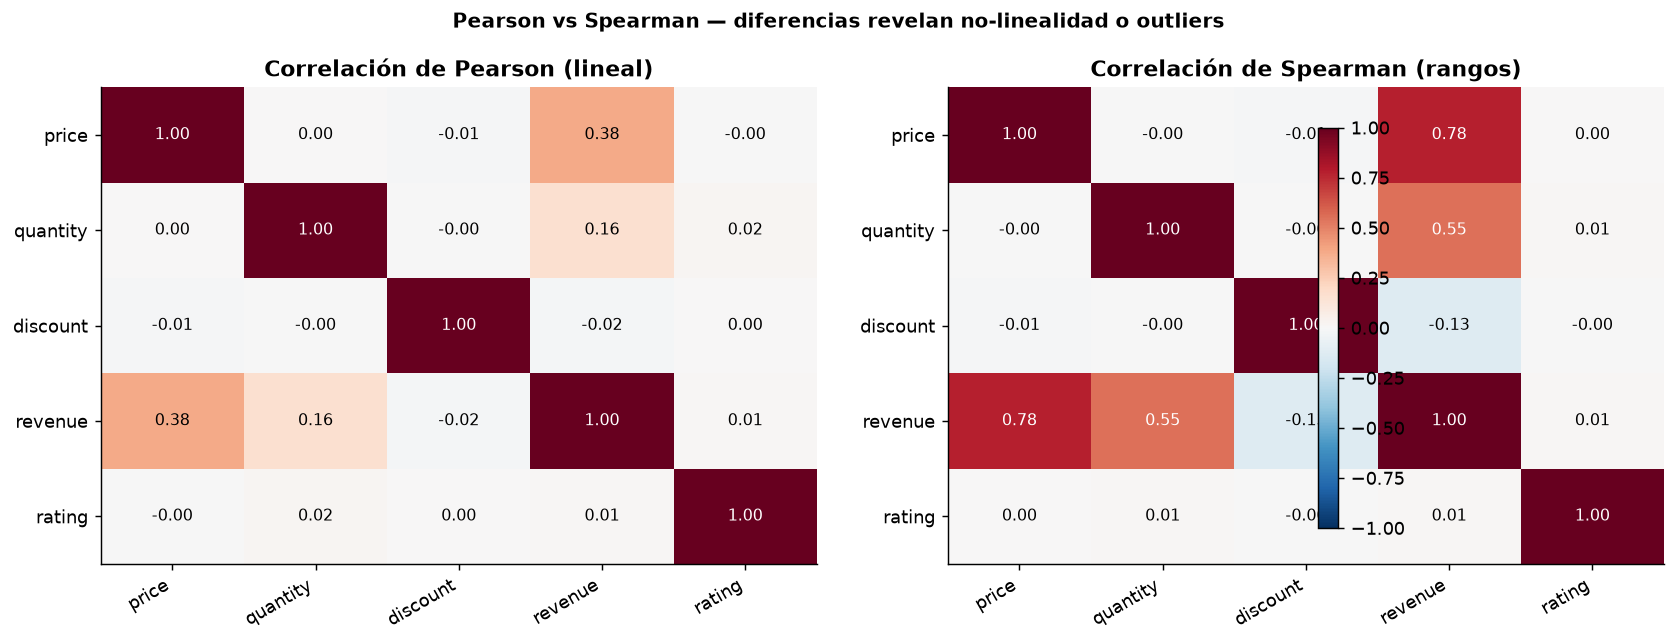

Diferencias grandes entre Pearson y Spearman → relación no lineal o outliers influyentes.


In [3]:
num_cols = ['price', 'quantity', 'discount', 'revenue', 'rating']

corr_pearson  = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')

def plot_heatmap(corr, ax, title):
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=30, ha='right')
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    ax.grid(False)
    for i in range(len(corr)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if abs(val) > 0.5 else 'black')
    return im

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = plot_heatmap(corr_pearson,  axes[0], 'Correlación de Pearson (lineal)')
plot_heatmap(corr_spearman, axes[1], 'Correlación de Spearman (rangos)')
plt.colorbar(im, ax=axes, shrink=0.8)
plt.suptitle('Pearson vs Spearman — diferencias revelan no-linealidad o outliers', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Diferencias grandes entre Pearson y Spearman → relación no lineal o outliers influyentes.')

## 3 — Numérica vs. Categórica: distribución por grupo

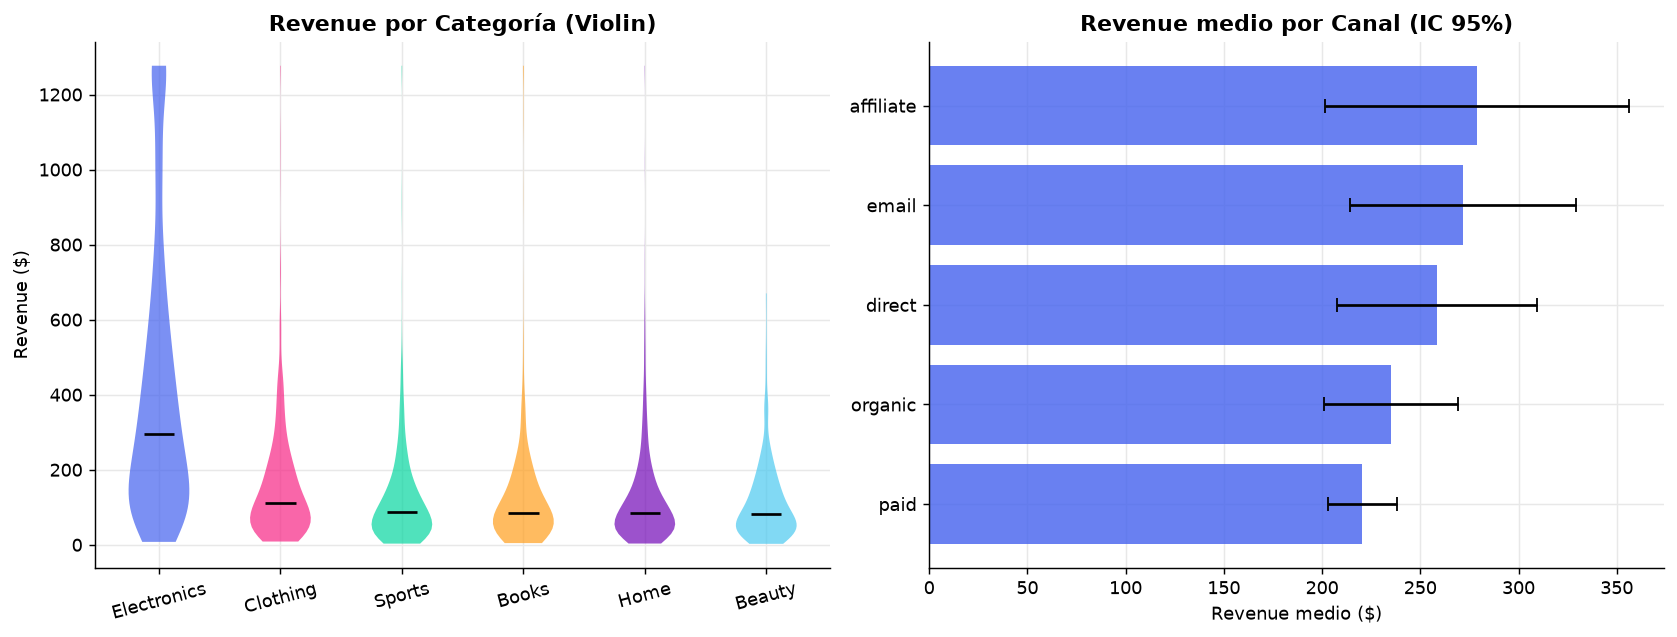

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7','#4cc9f0']

# Violin plot: revenue por categoría
cat_order = df.groupby('category')['revenue'].median().sort_values(ascending=False).index.tolist()
data_vio   = [df[df['category']==c]['revenue'].clip(upper=df['revenue'].quantile(0.98)).values for c in cat_order]
vp = axes[0].violinplot(data_vio, showmedians=True, showextrema=False)
for i, (body, color) in enumerate(zip(vp['bodies'], colors)):
    body.set_facecolor(color); body.set_alpha(0.7)
vp['cmedians'].set_color('black')
axes[0].set_xticks(range(1, len(cat_order)+1))
axes[0].set_xticklabels(cat_order, rotation=15)
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Revenue por Categoría (Violin)')

# Revenue medio por canal con IC
ch_stats = df.groupby('channel')['revenue'].agg(['mean','std','count']).reset_index()
ch_stats['se'] = ch_stats['std'] / np.sqrt(ch_stats['count'])
ch_stats['ci'] = 1.96 * ch_stats['se']
ch_stats = ch_stats.sort_values('mean', ascending=True)

axes[1].barh(ch_stats['channel'], ch_stats['mean'], xerr=ch_stats['ci'],
             color='#4361ee', alpha=0.8, capsize=4)
axes[1].set_xlabel('Revenue medio ($)')
axes[1].set_title('Revenue medio por Canal (IC 95%)')

plt.tight_layout()
plt.show()

## 4 — Cramér's V: asociación entre categóricas

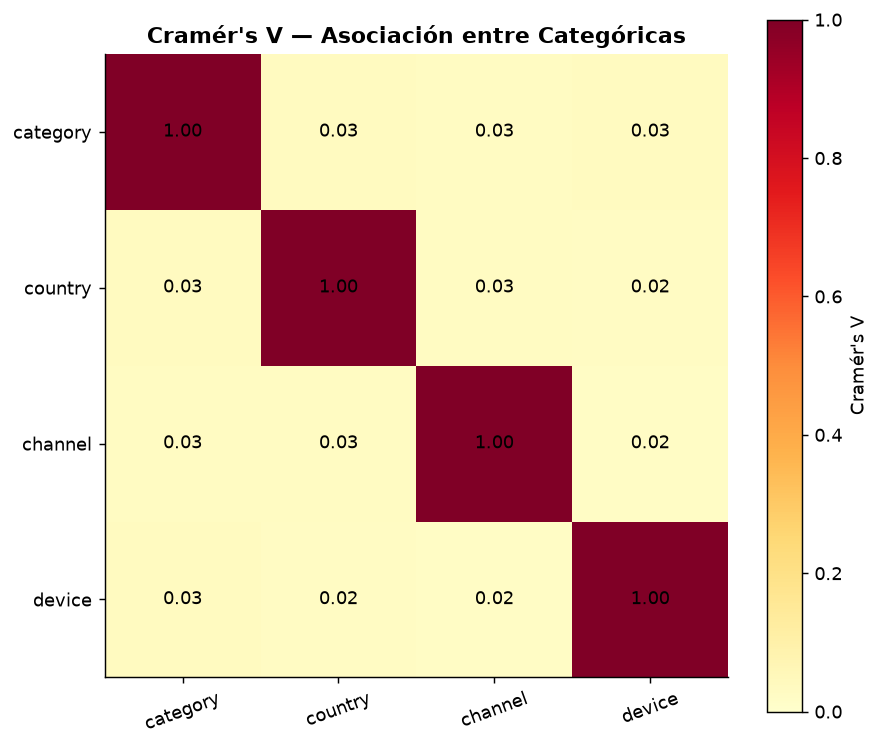

Diagonal = 1 siempre. V > 0.3 sugiere asociación moderada. V > 0.5 fuerte.


In [5]:
def cramers_v(x, y):
    ct  = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n    = ct.sum().sum()
    r, c = ct.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

cat_cols = ['category', 'country', 'channel', 'device']
cv_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cv_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cv_matrix.values.astype(float), cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(cat_cols))); ax.set_yticks(range(len(cat_cols)))
ax.set_xticklabels(cat_cols, rotation=20)
ax.set_yticklabels(cat_cols)
ax.set_title("Cramér's V — Asociación entre Categóricas")
ax.grid(False)
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        ax.text(j, i, f"{cv_matrix.iloc[i,j]:.2f}", ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='Cramér\'s V')
plt.tight_layout()
plt.show()
print('Diagonal = 1 siempre. V > 0.3 sugiere asociación moderada. V > 0.5 fuerte.')

## 5 — Pair plot: visión panorámica multivariada

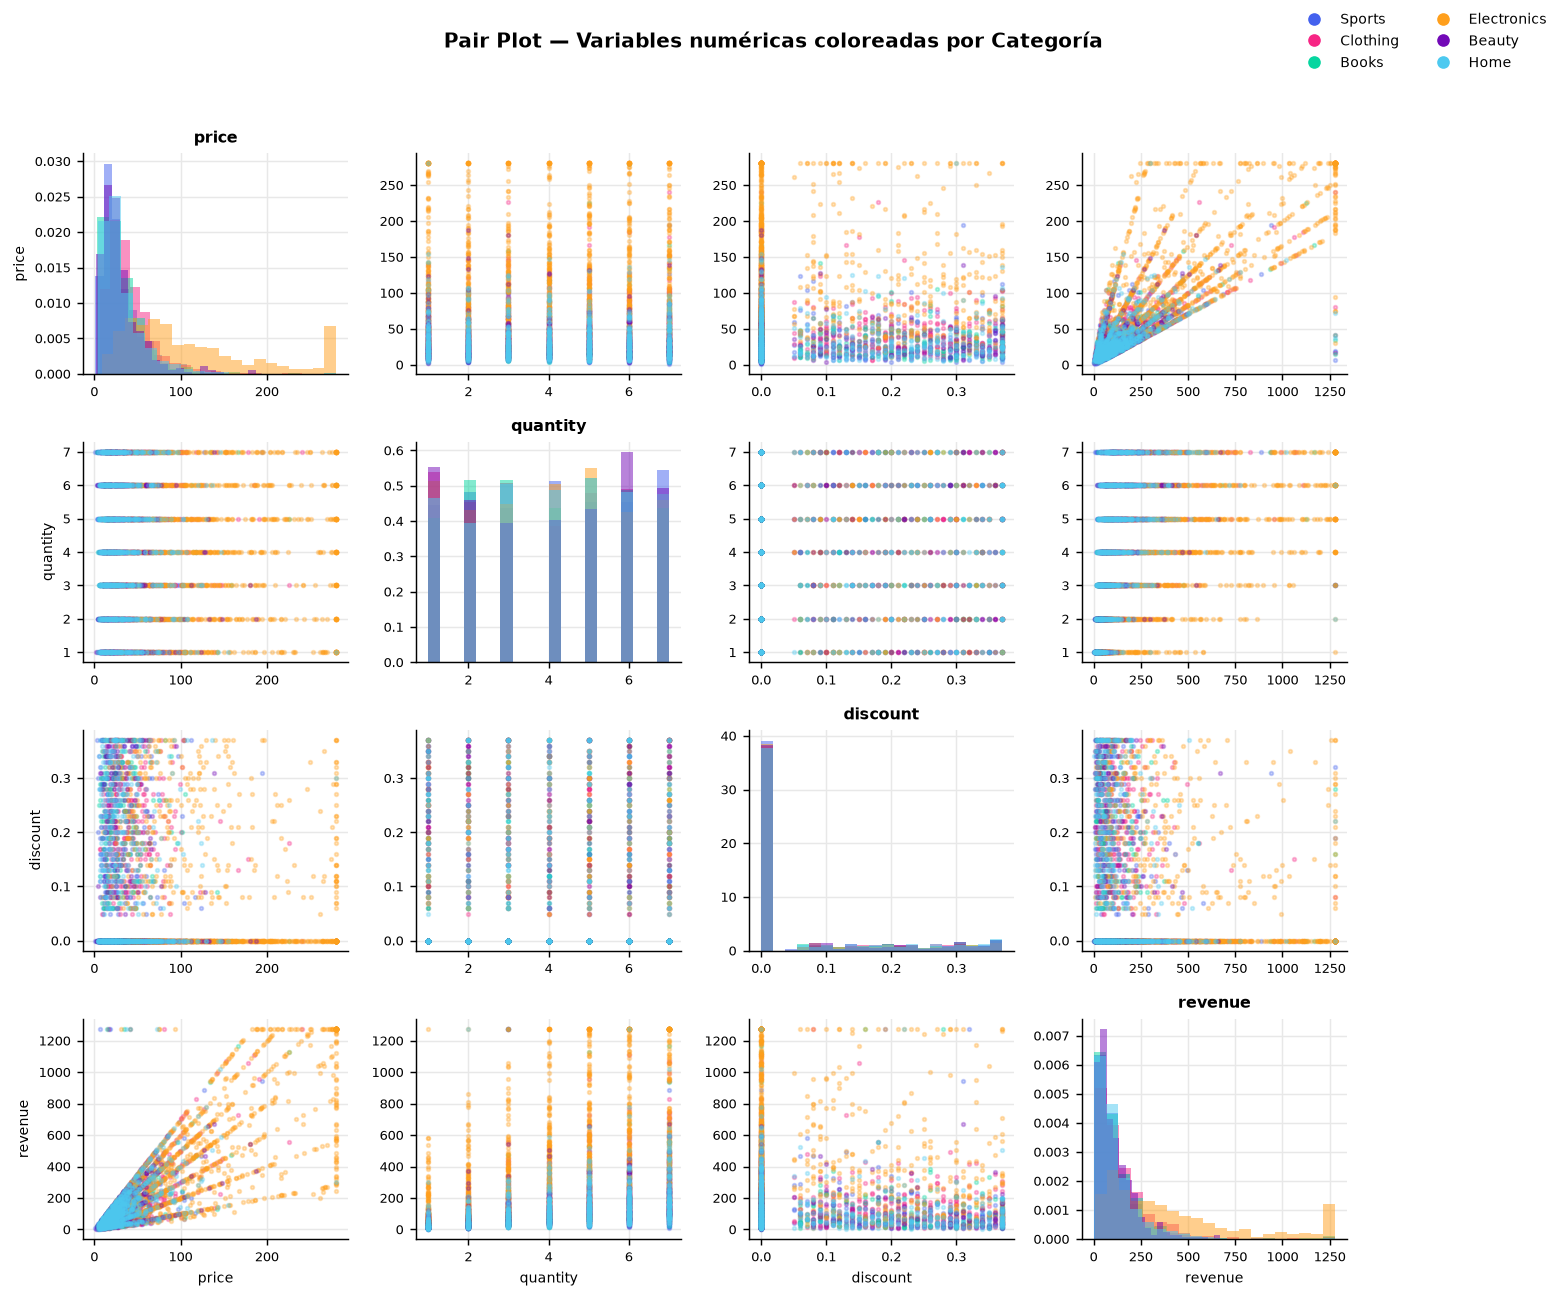

In [6]:
num_cols = ['price', 'quantity', 'discount', 'revenue']
df_plot  = df[num_cols + ['category']].copy()
# Clipear outliers para visualización
for c in num_cols:
    df_plot[c] = df_plot[c].clip(upper=df_plot[c].quantile(0.98))

cat_vals = df_plot['category'].unique()
colors   = ['#4361ee','#f72585','#06d6a0','#ff9f1c','#7209b7','#4cc9f0']
color_map = dict(zip(cat_vals, colors))

k = len(num_cols)
fig, axes = plt.subplots(k, k, figsize=(12, 10))

for i, col_y in enumerate(num_cols):
    for j, col_x in enumerate(num_cols):
        ax = axes[i, j]
        if i == j:
            for cat, color in color_map.items():
                ax.hist(df_plot[df_plot['category']==cat][col_x], bins=20,
                        color=color, alpha=0.5, density=True)
            ax.set_title(col_x, fontsize=9, fontweight='bold')
        else:
            for cat, color in color_map.items():
                mask = df_plot['category'] == cat
                ax.scatter(df_plot.loc[mask, col_x], df_plot.loc[mask, col_y],
                           s=4, alpha=0.3, color=color)
        if j == 0: ax.set_ylabel(col_y, fontsize=8)
        if i == k-1: ax.set_xlabel(col_x, fontsize=8)
        ax.tick_params(labelsize=7)

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=cat)
           for cat, c in color_map.items()]
fig.legend(handles=handles, loc='upper right', fontsize=8, ncol=2)
plt.suptitle('Pair Plot — Variables numéricas coloreadas por Categoría', fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.88, 0.95])
plt.show()

## Resumen

| Tipo de relación | Herramienta | Métrica |
|---|---|---|
| Numérica vs. Numérica | Scatter + línea de tendencia | Pearson r, Spearman ρ |
| Todas las numéricas | Heatmap de correlaciones | Pearson / Spearman |
| Numérica vs. Categórica | Violin / Box / Barras con IC | ANOVA, Kruskal-Wallis |
| Categórica vs. Categórica | Crosstab + Heatmap | Cramér's V, Chi² |
| Visión general | Pair plot | Todas las pares |

**Siguiente:** `04_time_series_eda.ipynb`